## EXPLORE DATA PATHS

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory
import os
count = 0
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        count += 1
        if count == 10:
            break
    if count==10:
        break





# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_359.jpg
/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_315.jpg
/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_321.jpg
/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_313.jpg
/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_322.jpg
/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_360.jpg
/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_361.jpg
/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_362.jpg
/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_310.jpg
/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_314.jpg


## DATASET CLASS 

In [2]:
from torch.utils.data import Dataset
import os
from PIL import Image
import cv2

path = "/kaggle/input/fire-detection-from-cctv/data"

class Fire_Dataset(Dataset):
    def __init__(self, root_dir, transform=None, frames_per_video=10, include_test_videos=False):
        self.root_dir = root_dir
        self.transform = transform
        self.frames_per_video = frames_per_video
        self.include_test_videos = include_test_videos
        self.samples = []
        self.error_logs = []
        self._load_data()
    
    def _load_data(self):
        image_exts = ["jpg", "jpeg", "png"]
        video_exts = ["mp4", "avi", "mov"]
        
        for root, _, files in os.walk(self.root_dir):
            for f in files:
                ext = f.split(".")[-1].lower()
                full_path = os.path.join(root, f)
                
                try:
                    # Determine label based on folder structure
                    label = self._get_label(root, f)
                    
                    # Skip unlabeled test videos unless explicitly included
                    if label is None:
                        if self.include_test_videos:
                            self.samples.append((full_path, -1, "video"))  # -1 for unlabeled
                        continue
                    
                    # for images
                    if ext in image_exts:
                        self.samples.append((full_path, label, "image"))
                    
                    # for videos: extract frames
                    elif ext in video_exts:
                        frames = self._extract_frames(full_path)
                        for frame in frames:
                            self.samples.append((frame, label, "frame"))
                
                except Exception as e:
                    self.error_logs.append((full_path, str(e)))
    
    def _get_label(self, root, filename):
        """
        Determine label based on directory structure and filename
        Returns: 0 (No Fire), 1 (Fire), or None (unlabeled)
        """
        root_lower = root.lower()
        filename_lower = filename.lower()
        
        # For image data
        if "img_data" in root_lower:
            if "default" in root_lower:
                return 0  # No Fire
            elif "fire" in root_lower or "smoke" in root_lower:
                return 1  # Fire
        
        # For video data
        elif "video_data" in root_lower:
            # test_videos are unlabeled
            if "test_videos" in root_lower:
                return None  # Unlabeled
            
            # train_videos - check filename
            elif "train_videos" in root_lower:
                if "fire" in filename_lower or "smoke" in filename_lower:
                    return 1  # Fire
                elif "nofire" in filename_lower:
                    return 0  # No Fire
        
        return None  # Unknown/unlabeled
    
    def _extract_frames(self, video_path):
        """Extract frames from video uniformly"""
        frames = []
        cap = cv2.VideoCapture(video_path)
        
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        
        if total_frames == 0:
            cap.release()
            return frames
        
        # Calculate frame indices to extract uniformly across the video
        frame_indices = [int(i * total_frames / self.frames_per_video) 
                        for i in range(self.frames_per_video)]
        
        for idx in frame_indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                # Convert BGR to RGB
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
        
        cap.release()
        return frames
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        data, label, data_type = self.samples[idx]
        
        if data_type == "image":
            # Load image from file
            img = Image.open(data).convert("RGB")
            if self.transform is not None:
                img = self.transform(img)
            return img, label
        
        elif data_type == "frame":
            # Convert numpy array (frame) to PIL Image
            img = Image.fromarray(data)
            if self.transform is not None:
                img = self.transform(img)
            return img, label
        
        elif data_type == "video":
            # Return video path for unlabeled test videos
            return data, label

In [3]:
# Recreate dataset with updated labeling
dataset = Fire_Dataset(path, transform=None, frames_per_video=10, include_test_videos=False)

# Check label distribution
all_labels = [label for _, label, _ in dataset.samples]
print(f"Total samples: {len(all_labels)}")
print(f"Fire samples (1): {sum([1 for l in all_labels if l == 1])}")
print(f"No-fire samples (0): {sum([1 for l in all_labels if l == 0])}")
print(f"Unlabeled samples (-1): {sum([1 for l in all_labels if l == -1])}")

Total samples: 1968
Fire samples (1): 1478
No-fire samples (0): 490
Unlabeled samples (-1): 0


In [4]:
dataset = Fire_Dataset(root_dir=path)
print(dataset.samples[:5])


[('/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_359.jpg', 1, 'image'), ('/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_315.jpg', 1, 'image'), ('/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_321.jpg', 1, 'image'), ('/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_313.jpg', 1, 'image'), ('/kaggle/input/fire-detection-from-cctv/data/img_data/test/smoke/img_322.jpg', 1, 'image')]


In [5]:
print(len(dataset))

1968


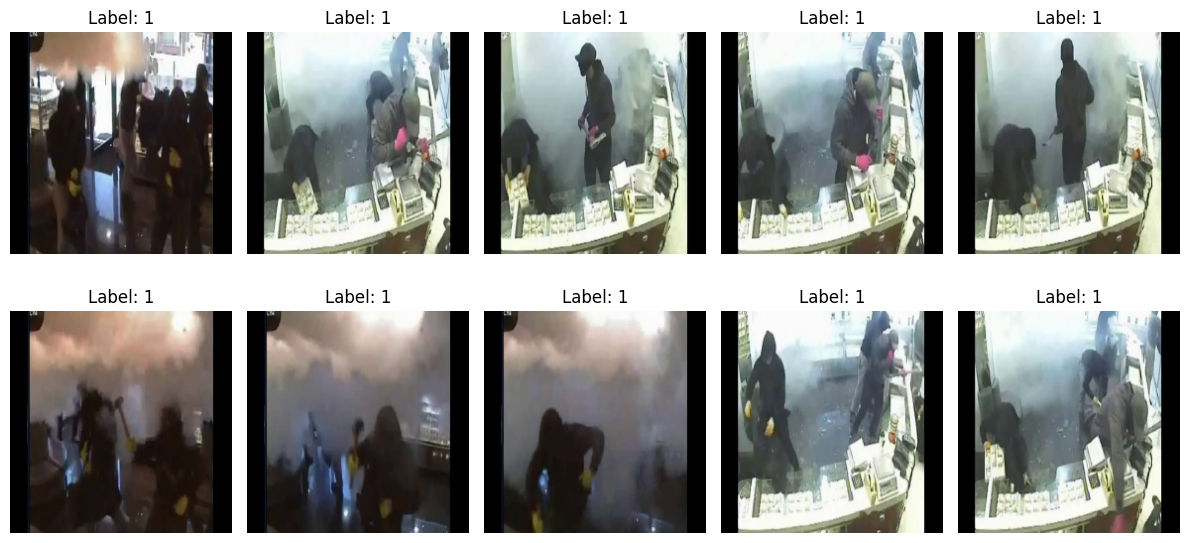

In [6]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12,6))

for i in range(10):
    x, y = dataset[i]
    plt.subplot(2, 5, i + 1) 
    plt.imshow(x)
    plt.title(f"Label: {y}")
    plt.axis('off')

plt.tight_layout()
plt.show()



In [7]:
for i in range(min(10, len(dataset.samples))):
    data, label, data_type = dataset.samples[i]
    print(i, label, data_type)

0 1 image
1 1 image
2 1 image
3 1 image
4 1 image
5 1 image
6 1 image
7 1 image
8 1 image
9 1 image


## DATA TRANSFORM

In [8]:
import torch
from torchvision import transforms
from PIL import Image

def get_mean_std(dataset):
    # Compose preprocessing: Resize all images to 128x128, then convert to Tensor
    preprocess = transforms.Compose([
        transforms.Resize((128,128)),  # Resize images to a fixed size
        transforms.ToTensor()          # Convert PIL Image to Tensor
    ])

    total_pixels = 0
    sum_pixels = torch.zeros(3, dtype=torch.float32)  # Sum for each channel R,G,B

    # First pass: compute mean
    for img, _ in dataset:
        # Skip videos or anything that is not an image
        if isinstance(img, str) or not isinstance(img, Image.Image):
            continue
        try:
            img_tensor = preprocess(img)  # Transform image
        except:
            continue
        pixels = img_tensor.view(3,-1)  # Flatten image to [C, pixels]
        sum_pixels += pixels.sum(dim=1) # Sum all pixels per channel
        total_pixels += pixels.size(1)  # Total number of pixels

    if total_pixels == 0:
        raise ValueError("No valid images found!")  # Ensure there are valid images

    mean = sum_pixels / total_pixels  # Compute mean for each channel

    # Second pass: compute standard deviation
    sum_squared_diff = torch.zeros(3, dtype=torch.float32)  # Accumulate squared differences
    for img, _ in dataset:
        if isinstance(img, str) or not isinstance(img, Image.Image):
            continue
        try:
            img_tensor = preprocess(img)
        except:
            continue
        pixels = img_tensor.view(3,-1)
        diff = pixels - mean.unsqueeze(1)  # Difference between each pixel and the mean
        sum_squared_diff += (diff ** 2).sum(dim=1)  # Sum of squared differences per channel

    std = torch.sqrt(sum_squared_diff / total_pixels)  # Compute standard deviation

    return mean, std


In [9]:
mean, std = get_mean_std(dataset)
print("Mean:", mean)
print("Std:", std)



Mean: tensor([0.4531, 0.4296, 0.4259])
Std: tensor([0.2693, 0.2699, 0.2708])


In [10]:
# Check all labels in your dataset
all_labels = [label for _, label, _ in dataset.samples]
print(f"Total Fire samples: {sum(all_labels)}")
print(f"Total No-fire samples: {len(all_labels) - sum(all_labels)}")

Total Fire samples: 1478
Total No-fire samples: 490


In [11]:
from torchvision import transforms

def augmentation_main_transform(mean, std):
    
    
    # Validation/Test transform 
    main_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    
    # Fire class training transform 
    fire_train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),  # Reduced from 0.5
        transforms.RandomRotation(15),
        transforms.GaussianBlur(kernel_size=3),
        transforms.ColorJitter(
            brightness=0.2,
            contrast=0.2,
            saturation=0.2,
            hue=0.1
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    
    # No-fire class training transform (minority class)
    no_fire_train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.3),
        transforms.RandomRotation(25),  # More rotation than fire
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
        transforms.RandomErasing(p=0.2)
    ])
    
    return main_transform, fire_train_transform, no_fire_train_transform

In [12]:
main_transform, fire_train_transform,no_fire_train_transform = augmentation_main_transform(mean, std)

## SPLITTING DATA TO DATA LOADERS

In [13]:
from torch.utils.data import Subset

class Subset_Dataset(Dataset):
    def __init__(self,subset:Subset,main_transform,fire_train_transform,no_fire_train_transform,is_train=False):
        self.subset=subset
        self.main_transform=main_transform
        self.fire_train_transform=fire_train_transform
        self.no_fire_train_transform=no_fire_train_transform
        self.is_train=is_train
   
    
    
    def __len__(self):
        return(len(self.subset))

    
    
    
    def __getitem__(self,idx):
        image,label=self.subset[idx]
        if self.is_train:
            if label==0:
                image=self.no_fire_train_transform(image)
            else:
                image=self.fire_train_transform(image)
        else:
            image=self.main_transform(image)
        return image,label

In [14]:
print(len(dataset))

1968


In [15]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader
def data_loader(dataset:Dataset,batch_size,
                train_fac,val_fac,test_fac,main_transform,fire_train_transform,no_fire_train_transform):
    
    
    
    total_size=len(dataset)
    
    train_size=int(total_size*train_fac)
    val_size=int(total_size*val_fac)
    test_size=total_size-train_size-val_size
    
    
    train_dataset,val_dataset,test_dataset=random_split(dataset,[train_size,val_size,test_size])
    
    
    train_dataset=Subset_Dataset(train_dataset,main_transform,fire_train_transform,no_fire_train_transform,is_train=True)
    
    val_dataset=Subset_Dataset(val_dataset,main_transform,fire_train_transform,no_fire_train_transform,is_train=False)
    
    test_dataset=Subset_Dataset(test_dataset,main_transform,fire_train_transform,no_fire_train_transform,is_train=False)
    
    
    train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
    
    val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False)
    
    test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)
    
    
    return train_loader,val_loader,test_loader

In [16]:
train_loader,val_loader,test_loader=data_loader(dataset,batch_size=8,
                                                train_fac=0.8,val_fac=0.1,test_fac=0.1,
                                                main_transform=main_transform,
                                                fire_train_transform=fire_train_transform,
                                                no_fire_train_transform=no_fire_train_transform)

In [17]:
print(f"Training samples: {len(train_loader)}")
print(f"Validation samples: {len(val_loader)}")
print(f"test samples: {len(test_loader)}")

Training samples: 197
Validation samples: 25
test samples: 25


In [18]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU'}")



print(f"Training samples: {len(train_loader)}")
print(f"Validation samples: {len(val_loader)}")
print(f"test samples: {len(test_loader)}")

Using device: cuda
GPU Name: Tesla T4
Training samples: 197
Validation samples: 25
test samples: 25


## DESIGN BASE LINE CNN MODEL

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

# Define CNN Model
class FireDetectionModel(nn.Module):
    def __init__(self):
        super(FireDetectionModel, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.batch_nor1=nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.batch_nor2=nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.batch_nor3=nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        
        
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.batch_nor4 =nn.BatchNorm2d(256)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(2, 2)

        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.batch_nor5=nn.BatchNorm2d(512)
        self.relu5= nn.ReLU()
        self.pool5 = nn.MaxPool2d(2, 2)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        
        
        self.fc1 = nn.Linear(512, 128)
        self.relu6 = nn.ReLU()

        self.fc2 = nn.Linear(128, 64)
        self.relu7 = nn.ReLU()
        
        self.dropout = nn.Dropout(0.5)
        self.fc3 = nn.Linear(64, 1)
        self.sigmoid=nn.Sigmoid()
        
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.batch_nor1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.batch_nor2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        
        x = self.conv3(x)
        x= self.batch_nor3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        x = self.conv4(x)
        x= self.batch_nor4(x)
        x = self.relu4(x)
        

        x = self.conv5(x)
        x= self.batch_nor5(x)
        x = self.relu5(x)
        

        x=self.adaptive_pool(x)
        
        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = self.relu6(x)
        x = self.dropout(x)
        
        x = self.fc2(x)
        x = self.relu7(x)
        
        x = self.dropout(x)
        x = self.fc3(x)
        
        
        
        return x








In [20]:
import torch
import gc

# Clear everything from GPU
torch.cuda.empty_cache()
gc.collect()

# Check GPU memory
print(f"GPU Memory allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")
print(f"GPU Memory cached: {torch.cuda.memory_reserved(0) / 1024**2:.2f} MB")

GPU Memory allocated: 0.00 MB
GPU Memory cached: 0.00 MB


## TRAIN

In [21]:
# Initialize model
num_fire = 1478
num_no_fire = 490
pos_weight = torch.tensor([num_no_fire / num_fire]).to(device)

model = FireDetectionModel().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, patience=5):
    history = {
        'loss': [], 'accuracy': [],
        'val_loss': [], 'val_accuracy': []
    }
    
    best_val_loss = float('inf')
    epochs_no_improve = 0
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
        
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total
        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        
        history['loss'].append(avg_train_loss)
        history['accuracy'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_accuracy'].append(val_acc)
        
        print(f'Epoch {epoch+1}/{epochs}')
        print(f'loss: {avg_train_loss:.4f} - accuracy: {train_acc:.4f} - val_loss: {avg_val_loss:.4f} - val_accuracy: {val_acc:.4f}')
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_model.pth')
            print(f'Validation loss improved, saving model...')
        else:
            epochs_no_improve += 1
            print(f'No improvement for {epochs_no_improve} epoch(s)')
        
        if epochs_no_improve >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs')
            model.load_state_dict(torch.load('best_model.pth'))
            break
    
    return history

In [22]:
# Train the model
history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=50)

Epoch 1/50
loss: 0.3126 - accuracy: 0.6970 - val_loss: 0.3010 - val_accuracy: 0.5612
Validation loss improved, saving model...
Epoch 2/50
loss: 0.2824 - accuracy: 0.7186 - val_loss: 0.2664 - val_accuracy: 0.6071
Validation loss improved, saving model...
Epoch 3/50
loss: 0.2747 - accuracy: 0.7471 - val_loss: 0.2556 - val_accuracy: 0.7296
Validation loss improved, saving model...
Epoch 4/50
loss: 0.2647 - accuracy: 0.7624 - val_loss: 0.2420 - val_accuracy: 0.8367
Validation loss improved, saving model...
Epoch 5/50
loss: 0.2612 - accuracy: 0.7624 - val_loss: 0.3027 - val_accuracy: 0.8010
No improvement for 1 epoch(s)
Epoch 6/50
loss: 0.2534 - accuracy: 0.7808 - val_loss: 0.2998 - val_accuracy: 0.6480
No improvement for 2 epoch(s)
Epoch 7/50
loss: 0.2418 - accuracy: 0.7732 - val_loss: 0.2614 - val_accuracy: 0.8163
No improvement for 3 epoch(s)
Epoch 8/50
loss: 0.2376 - accuracy: 0.7954 - val_loss: 0.2341 - val_accuracy: 0.8061
Validation loss improved, saving model...
Epoch 9/50
loss: 0.2

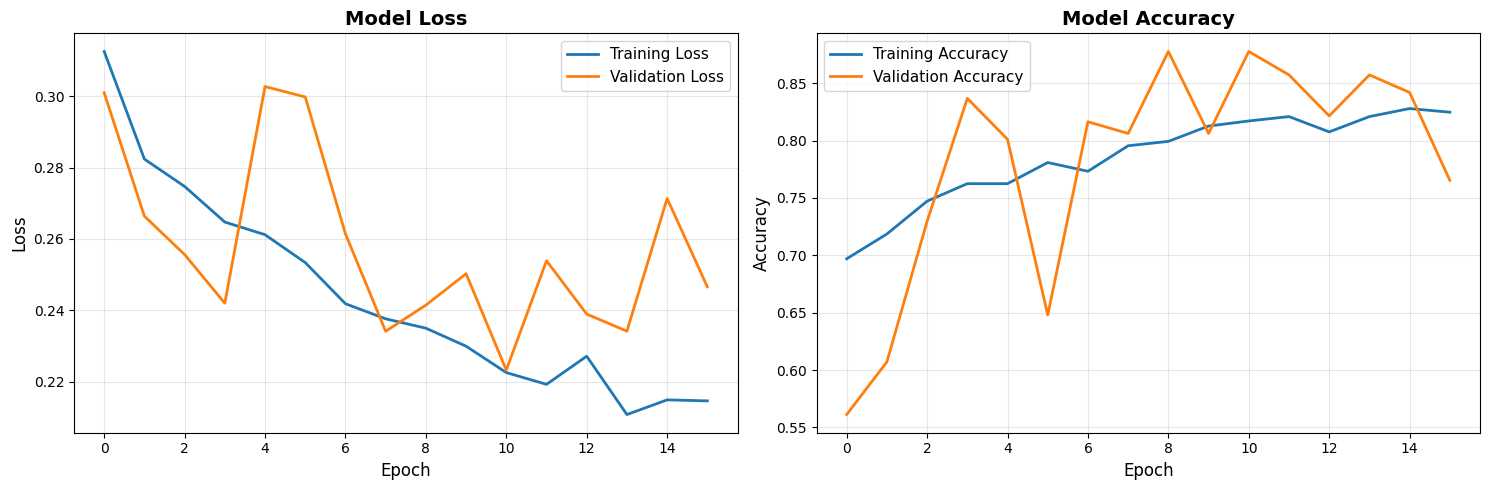

In [23]:
import matplotlib.pyplot as plt

# Plot training history
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot loss
    axes[0].plot(history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Plot accuracy
    axes[1].plot(history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[1].plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[1].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Call after training
plot_history(history)

## TRASFER LEARNING USING MOBILE-NET

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau

class MobileNetFireDetection(nn.Module):
    def __init__(self, pretrained=True):
        super(MobileNetFireDetection, self).__init__()
        
        self.mobilenet = models.mobilenet_v2(pretrained=pretrained)
        
        in_features = self.mobilenet.classifier[1].in_features
        
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, 1)
        )
    
    def forward(self, x):
        return self.mobilenet(x)

model_mobilenet = MobileNetFireDetection(pretrained=True).to(device)
print(model_mobilenet)

num_fire = 1478
num_no_fire = 490
pos_weight = torch.tensor([num_no_fire / num_fire]).to(device)

criterion_mobilenet = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_mobilenet = optim.Adam(model_mobilenet.parameters(), lr=0.0001)

# Add learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer_mobilenet, mode='min', factor=0.5, patience=3, verbose=True)





MobileNetFireDetection(
  (mobilenet): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, k

In [31]:
# Modified train_model function to save the best model based on validation accuracy
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=22, patience=5):
    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': []
    }
    
    best_val_loss = float('inf')
    best_val_accuracy = 0.0  # Track best accuracy
    patience_counter = 0
    best_model_state = None
    
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
            # Calculate accuracy
            preds = torch.sigmoid(outputs) > 0.5
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)
        
        train_loss = train_loss / len(train_loader)
        train_accuracy = train_correct / train_total
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                
                preds = torch.sigmoid(outputs) > 0.5
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        
        val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total
        
        # Update learning rate based on validation loss
        scheduler.step(val_loss)
        
        # Store history
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        
        print(f'Epoch {epoch+1}/{epochs}')
        print(f'  loss: {train_loss:.4f} - accuracy: {train_accuracy:.4f}')
        print(f'  val_loss: {val_loss:.4f} - val_accuracy: {val_accuracy:.4f}')
        
        # Track best validation accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            # Save the best model based on accuracy
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_accuracy': val_accuracy,
                'val_loss': val_loss,
            }, 'best_accuracy_model.pth')
            print(f'  Best validation accuracy improved to {val_accuracy:.4f}')
        
        # Early stopping check based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            print(f'  Validation loss improved')
        else:
            patience_counter += 1
            print(f'  No improvement for {patience_counter} epoch(s)')
            
            if patience_counter >= patience:
                print(f'\nEarly stopping triggered at epoch {epoch+1}')
                print(f'Best validation loss: {best_val_loss:.4f}')
                print(f'Best validation accuracy: {best_val_accuracy:.4f}')
                break
    
    return history, best_val_accuracy




history_mobilenet, best_acc = train_model(model_mobilenet, train_loader, val_loader, 
                                          criterion_mobilenet, optimizer_mobilenet, 
                                          scheduler, epochs=22, patience=5)

print(f"\nBest validation accuracy achieved: {best_acc:.4f}")

Epoch 1/22
  loss: 0.1610 - accuracy: 0.8520
  val_loss: 0.1933 - val_accuracy: 0.8163
  Best validation accuracy improved to 0.8163
  Validation loss improved
Epoch 2/22
  loss: 0.0888 - accuracy: 0.9168
  val_loss: 0.1215 - val_accuracy: 0.8622
  Best validation accuracy improved to 0.8622
  Validation loss improved
Epoch 3/22
  loss: 0.0810 - accuracy: 0.9358
  val_loss: 0.1062 - val_accuracy: 0.8878
  Best validation accuracy improved to 0.8878
  Validation loss improved
Epoch 4/22
  loss: 0.0682 - accuracy: 0.9498
  val_loss: 0.1543 - val_accuracy: 0.8214
  No improvement for 1 epoch(s)
Epoch 5/22
  loss: 0.0610 - accuracy: 0.9530
  val_loss: 0.2658 - val_accuracy: 0.7755
  No improvement for 2 epoch(s)
Epoch 6/22
  loss: 0.0550 - accuracy: 0.9536
  val_loss: 0.1604 - val_accuracy: 0.8724
  No improvement for 3 epoch(s)
Epoch 7/22
  loss: 0.0385 - accuracy: 0.9689
  val_loss: 0.1739 - val_accuracy: 0.8418
  No improvement for 4 epoch(s)
Epoch 8/22
  loss: 0.0417 - accuracy: 0.9714

In [39]:
# Save the complete model (architecture + weights)
torch.save({
    'epoch': 16,
    'model': model_mobilenet,  
    'model_state_dict': model_mobilenet.state_dict(),
    'val_accuracy': 0.9490,
    'val_loss': 0.0645,
    'num_classes': 1
}, 'mobile_net_model.pth')
print("Model saved successfully!")

Model saved successfully!


## EVALUATE MODEL ON TEST SET

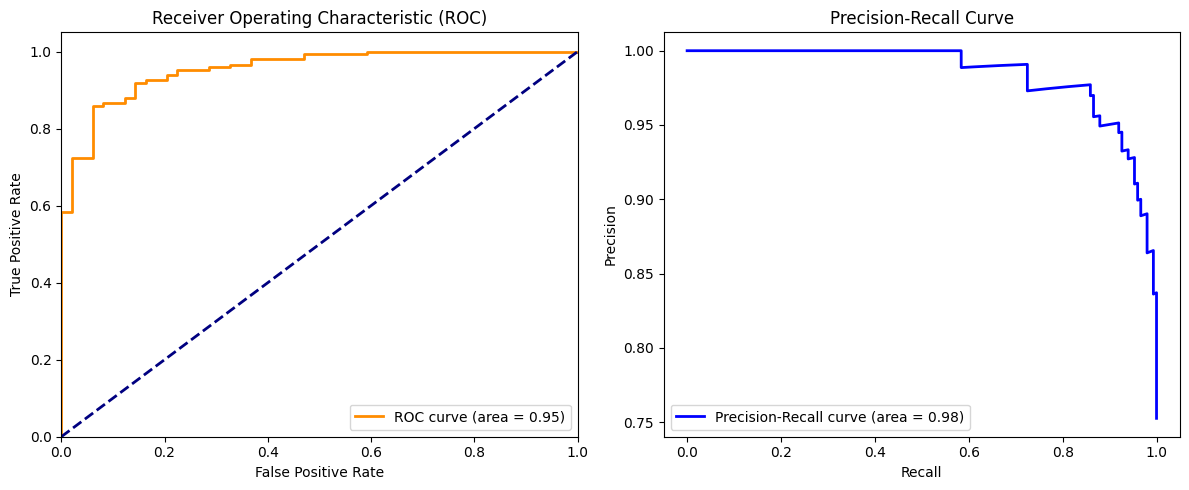

ROC AUC: 0.9548
Precision-Recall AUC: 0.9846
              precision    recall  f1-score   support

     No Fire       0.59      0.94      0.72        49
        Fire       0.97      0.79      0.87       149

    accuracy                           0.82       198
   macro avg       0.78      0.86      0.80       198
weighted avg       0.88      0.82      0.83       198

Confusion Matrix:
[[ 46   3]
 [ 32 117]]


In [40]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np


checkpoint = torch.load('mobile_net_model.pth', map_location=device, weights_only=False)

model_mobilenet.load_state_dict(checkpoint['model_state_dict'])


model_mobilenet.eval()


all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
        outputs = model_mobilenet(inputs)
        probs = torch.sigmoid(outputs) 
        
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)


fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)


precision, recall, _ = precision_recall_curve(all_labels, all_probs)
pr_auc = average_precision_score(all_labels, all_probs)


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")


plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()


print(f'ROC AUC: {roc_auc:.4f}')
print(f'Precision-Recall AUC: {pr_auc:.4f}')


from sklearn.metrics import classification_report, confusion_matrix

predictions = (all_probs > 0.5).astype(int)
print(classification_report(all_labels, predictions, target_names=['No Fire', 'Fire']))
print('Confusion Matrix:')
print(confusion_matrix(all_labels, predictions))

## SAVING MODEL

In [45]:
import torch
from torchvision import models
import torch.nn as nn

# Define the class
class MobileNetFireDetection(nn.Module):
    def __init__(self, num_classes=1):
        super(MobileNetFireDetection, self).__init__()
        self.mobilenet = models.mobilenet_v2(weights=None)
        self.mobilenet.classifier[1] = nn.Linear(
            self.mobilenet.classifier[1].in_features, 
            num_classes
        )
    
    def forward(self, x):
        return self.mobilenet(x)

# Load checkpoint
checkpoint = torch.load('mobile_net_model.pth', weights_only=False, map_location='cpu')

# Recreate and load model
model = MobileNetFireDetection(num_classes=1)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Save ONLY state_dict (cleaner approach)
torch.save({
    'epoch': checkpoint['epoch'],
    'model_state_dict': model.state_dict(),
    'val_accuracy': checkpoint['val_accuracy'],
    'val_loss': checkpoint['val_loss'],
}, 'best_mobile_accuracy_model.pth')

print("✅ Model re-saved with state_dict only!")

✅ Model re-saved with state_dict only!
